In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("winequality-red.csv",sep=";")

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.shape

(1599, 12)

In [8]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

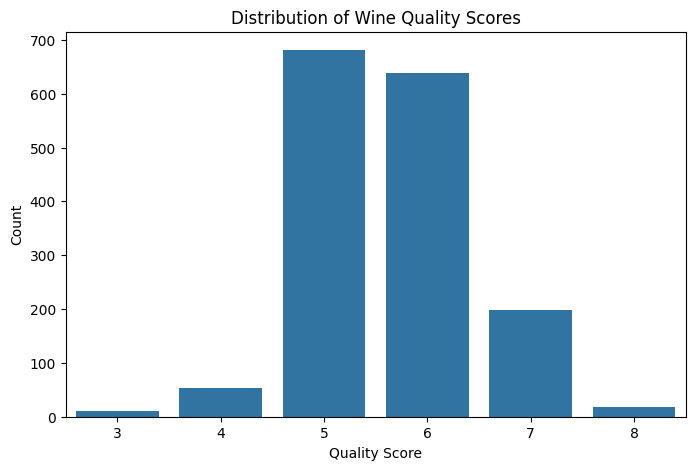

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

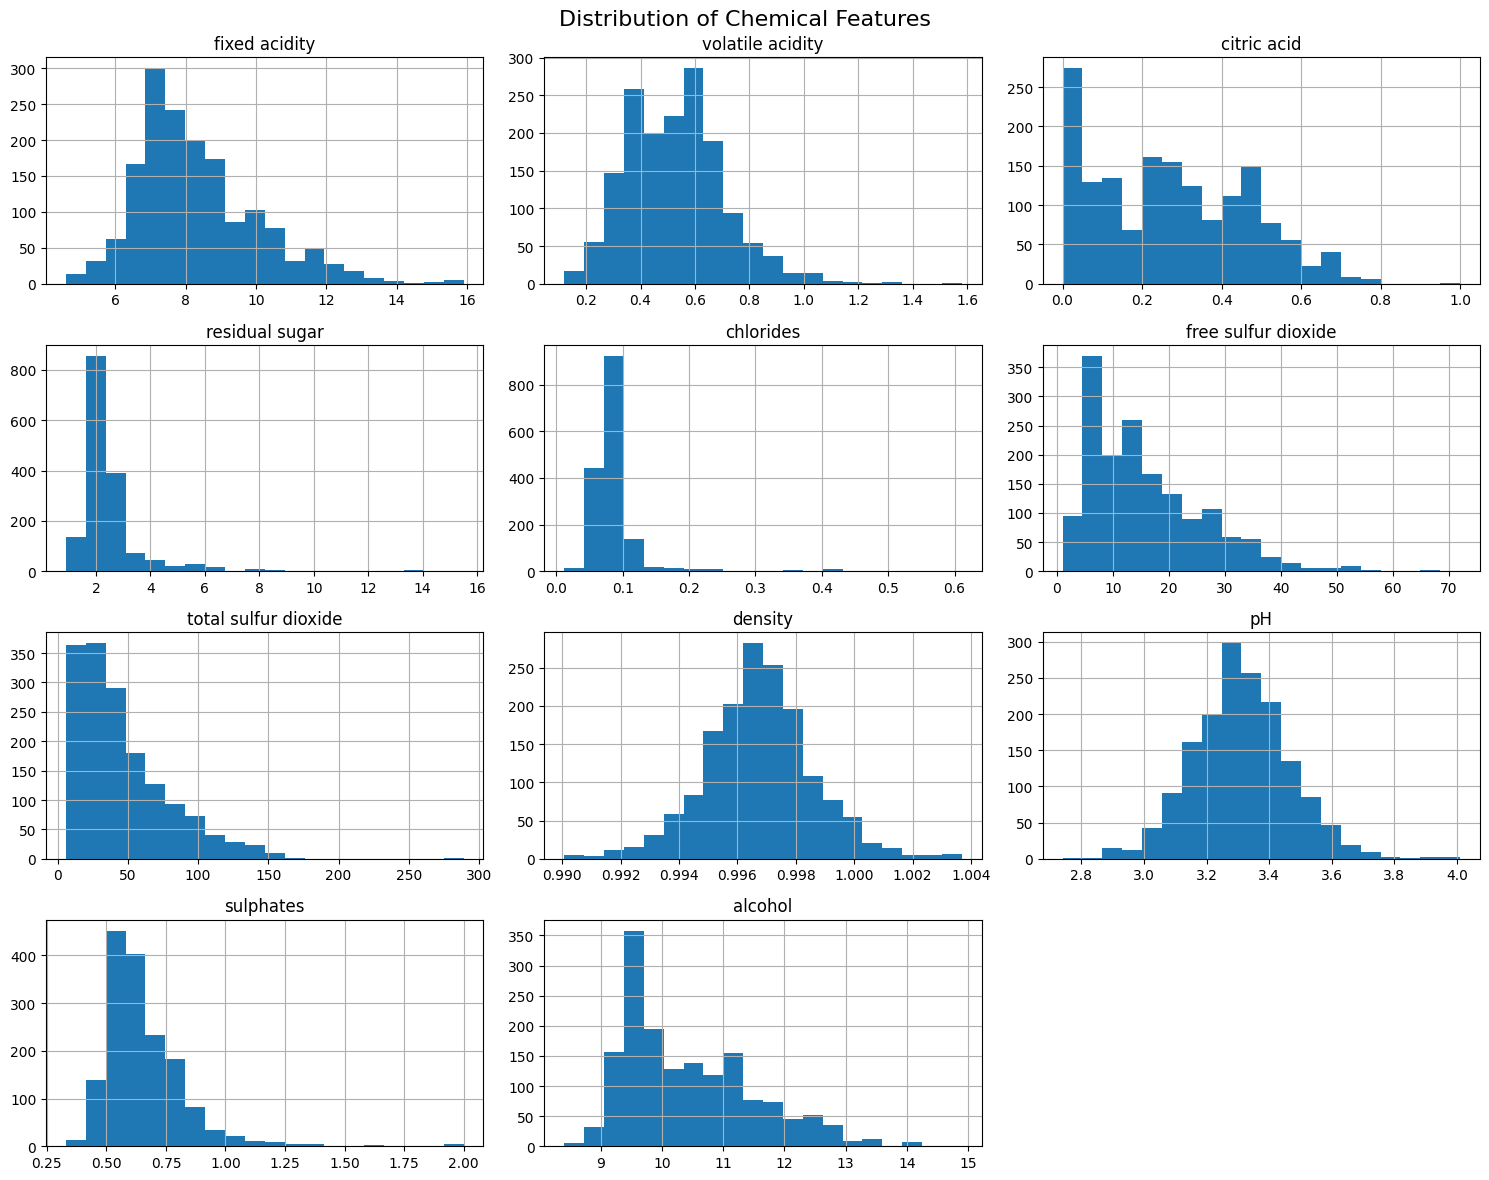

In [10]:
features = df.drop(columns='quality')

features.hist(figsize=(15, 12), bins=20)
plt.suptitle('Distribution of Chemical Features', fontsize=16)
plt.tight_layout()
plt.show()

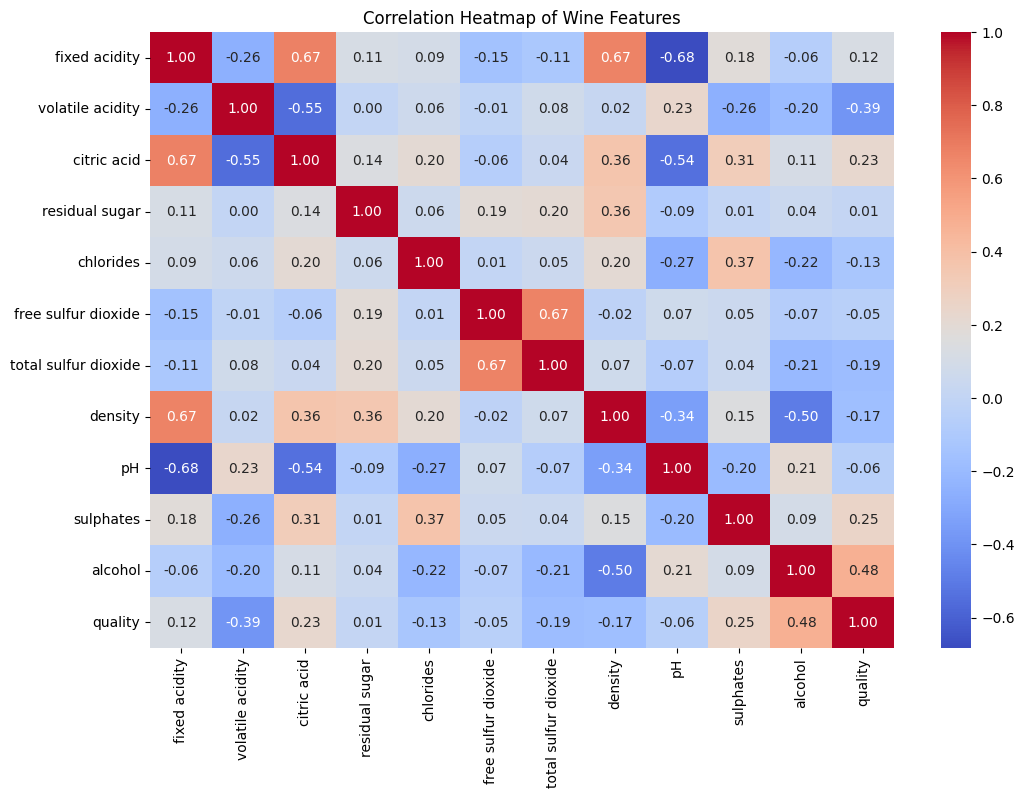

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Wine Features')
plt.show()

In [12]:
def quality_category(x):
    if x <= 5:
        return 'Low'
    elif x == 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_category)

df['quality_category'].value_counts()

quality_category
Low       744
Medium    638
High      217
Name: count, dtype: int64

In [13]:
X = df.drop(columns=['quality', 'quality_category'])
y = df['quality_category']

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 11)
y shape: (1599,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1279, 11)
Testing data shape: (320, 11)


In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [19]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.753125

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.58      0.64        43
         Low       0.80      0.83      0.82       149
      Medium       0.71      0.72      0.71       128

    accuracy                           0.75       320
   macro avg       0.74      0.71      0.72       320
weighted avg       0.75      0.75      0.75       320



In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (1279, 11)
Scaled testing data shape: (320, 11)


In [22]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_model.predict(X_test_scaled)

In [23]:
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print("SGD Classifier Accuracy:", sgd_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sgd))

SGD Classifier Accuracy: 0.596875

Classification Report:
              precision    recall  f1-score   support

        High       0.39      0.21      0.27        43
         Low       0.67      0.82      0.73       149
      Medium       0.53      0.47      0.50       128

    accuracy                           0.60       320
   macro avg       0.53      0.50      0.50       320
weighted avg       0.57      0.60      0.58       320



In [24]:
svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)

In [25]:
svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("SVC Accuracy:", svc_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

SVC Accuracy: 0.665625

Classification Report:
              precision    recall  f1-score   support

        High       0.65      0.40      0.49        43
         Low       0.71      0.80      0.75       149
      Medium       0.61      0.60      0.61       128

    accuracy                           0.67       320
   macro avg       0.66      0.60      0.62       320
weighted avg       0.66      0.67      0.66       320



In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
10               alcohol    0.150643
9              sulphates    0.114743
1       volatile acidity    0.110604
6   total sulfur dioxide    0.098726
7                density    0.090486
2            citric acid    0.079004
0          fixed acidity    0.073905
4              chlorides    0.073298
8                     pH    0.072261
3         residual sugar    0.069918
5    free sulfur dioxide    0.066413


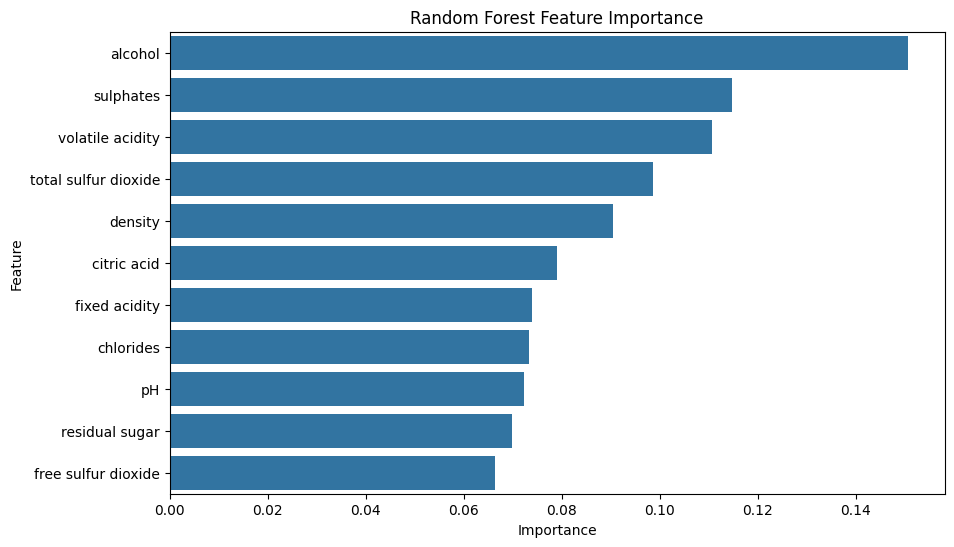

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

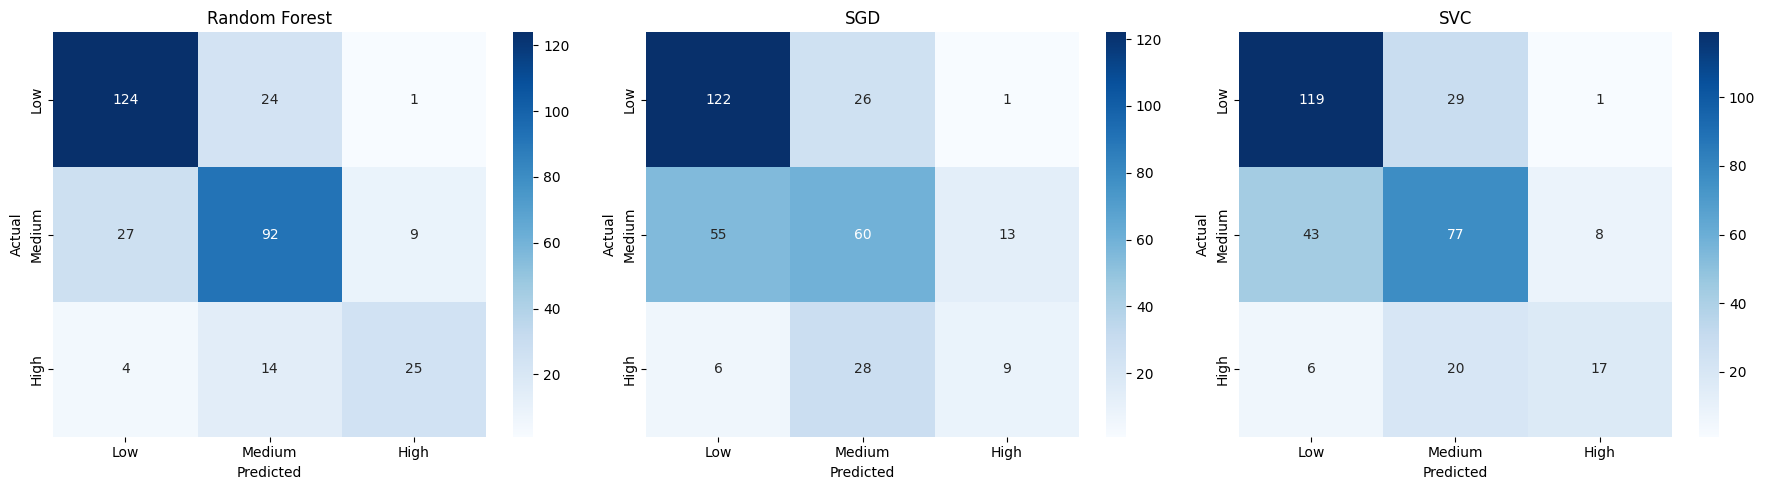

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Random Forest', y_pred_rf),
    ('SGD', y_pred_sgd),
    ('SVC', y_pred_svc)
]

for ax, (name, predictions) in zip(axes, models):
    cm = confusion_matrix(y_test, predictions, labels=['Low', 'Medium', 'High'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Low', 'Medium', 'High'],
        yticklabels=['Low', 'Medium', 'High'],
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [29]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [rf_accuracy, sgd_accuracy, svc_accuracy]
})

comparison['Accuracy'] = comparison['Accuracy'].round(4)

comparison

,Model,Accuracy
0,Random Forest,0.7531
1,SGD,0.5969
2,SVC,0.6656


In [30]:
best_model = comparison.loc[comparison['Accuracy'].idxmax()]

print("Best Model:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])

Best Model: Random Forest
Best Accuracy: 0.7531


## Conclusion

In this project, three classification models — Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC) — were trained to predict wine quality categories based on physicochemical properties.

Among the three models, Random Forest achieved the highest accuracy of **75.31%**, followed by SVC with **66.56%** and SGD with **59.69%**. Therefore, Random Forest was the most suitable model for this dataset.

The analysis also showed class imbalance, with fewer samples in the High-quality category compared with the Low and Medium categories. The Random Forest feature-importance analysis indicated that **alcohol, sulphates, and volatile acidity** were among the most influential features for predicting wine quality.

Overall, Random Forest provided the best predictive performance and would be the preferred model among the three tested models.
